In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from torchvision import datasets
from sklearn.model_selection import train_test_split

class NeuralNetwork:
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10,
                 activation='relu', init='he', lr=0.01, seed=42):

        np.random.seed(seed)

        self.lr = lr
        self.activation_name = activation


        if init == 'he':
            self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        elif init == 'xavier':
            self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(1 / input_dim)

        self.b1 = np.ones((1, hidden_dim))

        if init == 'he':
            self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2 / hidden_dim)
        elif init == 'xavier':
            self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(1 / hidden_dim)

        self.b2 = np.ones((1, output_dim))


    def activation(self, x):
        if self.activation_name == 'relu':
            return np.maximum(0, x)
        elif self.activation_name == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        elif self.activation_name == 'tanh':
            return np.tanh(x)

    def activation_derivative(self, x):
        if self.activation_name == 'relu':
            return (x > 0)
        elif self.activation_name == 'sigmoid':
            sig = 1 / (1 + np.exp(-x))
            return sig * (1 - sig)
        elif self.activation_name == 'tanh':
            return 1 - np.tanh(x)**2

    def softmax(self, x):
        exp = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp / np.sum(exp, axis=1, keepdims=True)


    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1      # [B,128]
        self.A1 = self.activation(self.Z1)   # [B,128]

        self.Z2 = self.A1 @ self.W2 + self.b2  # [B,10]
        self.A2 = self.softmax(self.Z2)        # [B,10]

        return self.A2


    def compute_loss(self, y_pred, y):
        m = y.shape[0]
        return -np.mean(np.log(y_pred[np.arange(m), y] + 1e-8))


    def backward(self, X, y):
        B = X.shape[0]

        # one-hot
        Y = np.zeros_like(self.A2)
        Y[np.arange(B), y] = 1


        dZ2 = self.A2 - Y                        # [B,10]

        dW2 = (self.A1.T @ dZ2) / B             # [128,10]
        db2 = np.sum(dZ2, axis=0, keepdims=True) / B

        dA1 = dZ2 @ self.W2.T                   # [B,128]


        dZ1 = dA1 * self.activation_derivative(self.Z1)

        dW1 = (X.T @ dZ1) / B                  # [784,128]
        db1 = np.sum(dZ1, axis=0, keepdims=True) / B

        return dW1, db1, dW2, db2


    def update(self, dW1, db1, dW2, db2):
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2


    def train(self, X, y, epochs=25, batch_size=64):

        losses = []
        accs = []

        for epoch in range(epochs):

            epoch_loss = 0
            total = 0

            for X_batch, y_batch in get_batches(X, y, batch_size):

                y_pred = self.forward(X_batch)

                loss = self.compute_loss(y_pred, y_batch)
                epoch_loss += loss * len(X_batch)

                dW1, db1, dW2, db2 = self.backward(X_batch, y_batch)
                self.update(dW1, db1, dW2, db2)

                total += len(X_batch)

            epoch_loss /= total

            preds = self.predict(X)
            acc = np.mean(preds == y)

            losses.append(epoch_loss)
            accs.append(acc)

            print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={acc:.4f}")

        return losses, accs


    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

In [ ]:
# train
train_data = datasets.MNIST(root='./data', train=True, download=True)
X = train_data.data.numpy().reshape(-1, 784) / 255.0
y = train_data.targets.numpy()

# test
test_data = datasets.MNIST(root='./data', train=False, download=True)
X_test = test_data.data.numpy().reshape(-1, 784) / 255.0
y_test = test_data.targets.numpy()

In [ ]:
def get_batches(X, y, batch_size=64):
    indices = np.random.permutation(len(X))

    for i in range(0, len(X), batch_size):
        batch_idx = indices[i:i+batch_size]
        yield X[batch_idx], y[batch_idx]

In [ ]:
splits = {
    "70_30": 0.3,
    "80_20": 0.2,
    "90_10": 0.1
}
configs = [
    ('he', 'relu'),
    ('xavier', 'relu'),
    ('he', 'sigmoid'),
    ('xavier', 'sigmoid'),
    ('he', 'tanh'),
    ('xavier', 'tanh'),
]


In [ ]:
all_results = {}

for split_name, test_size in splits.items():

    print(f"\n==================== {split_name} ====================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    split_results = {}

    for init, act in configs:

        config_name = f"{init}_{act}"
        print(f"\n Running: {config_name}")

        model = NeuralNetwork(
            activation=act,
            init=init,
            lr=0.01
        )

        losses, accs = model.train(
            X_train, y_train,
            epochs=20,
            batch_size=64
        )

        y_pred = model.predict(X_test)

        test_acc = np.mean(y_pred == y_test)
        cm = confusion_matrix(y_test, y_pred)

        split_results[config_name] = {
            "losses": losses,
            "accs": accs,
            "test_acc": test_acc,
            "conf_matrix": cm
        }

        print(f"Test Accuracy: {test_acc:.4f}")

    all_results[split_name] = split_results


==================== 70_30 ====================

 Running: he_relu
Epoch 1: Loss=0.8472, Acc=0.8656
Epoch 2: Loss=0.4462, Acc=0.8856
Epoch 3: Loss=0.3852, Acc=0.8948
Epoch 4: Loss=0.3554, Acc=0.9015
Epoch 5: Loss=0.3365, Acc=0.9058
Epoch 6: Loss=0.3227, Acc=0.9081
Epoch 7: Loss=0.3116, Acc=0.9107
Epoch 8: Loss=0.3022, Acc=0.9144
Epoch 9: Loss=0.2942, Acc=0.9170
Epoch 10: Loss=0.2865, Acc=0.9190
Epoch 11: Loss=0.2799, Acc=0.9215
Epoch 12: Loss=0.2731, Acc=0.9235
Epoch 13: Loss=0.2672, Acc=0.9250
Epoch 14: Loss=0.2614, Acc=0.9270
Epoch 15: Loss=0.2553, Acc=0.9287
Epoch 16: Loss=0.2497, Acc=0.9302
Epoch 17: Loss=0.2443, Acc=0.9323
Epoch 18: Loss=0.2393, Acc=0.9333
Epoch 19: Loss=0.2337, Acc=0.9355
Epoch 20: Loss=0.2290, Acc=0.9350
Test Accuracy: 0.9306

 Running: xavier_relu
Epoch 1: Loss=0.9926, Acc=0.8606
Epoch 2: Loss=0.4844, Acc=0.8819
Epoch 3: Loss=0.4053, Acc=0.8925
Epoch 4: Loss=0.3698, Acc=0.8980
Epoch 5: Loss=0.3484, Acc=0.9025
Epoch 6: Loss=0.3332, Acc=0.9057
Epoch 7: Loss=0.32

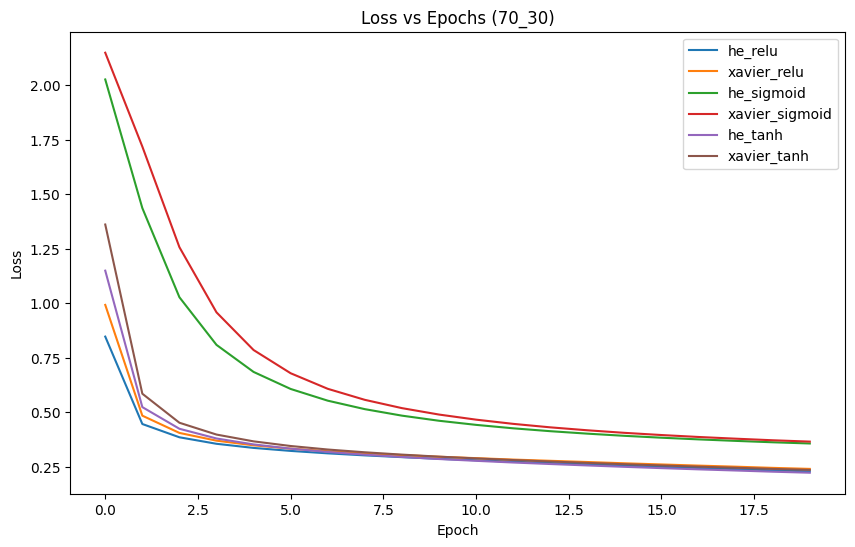

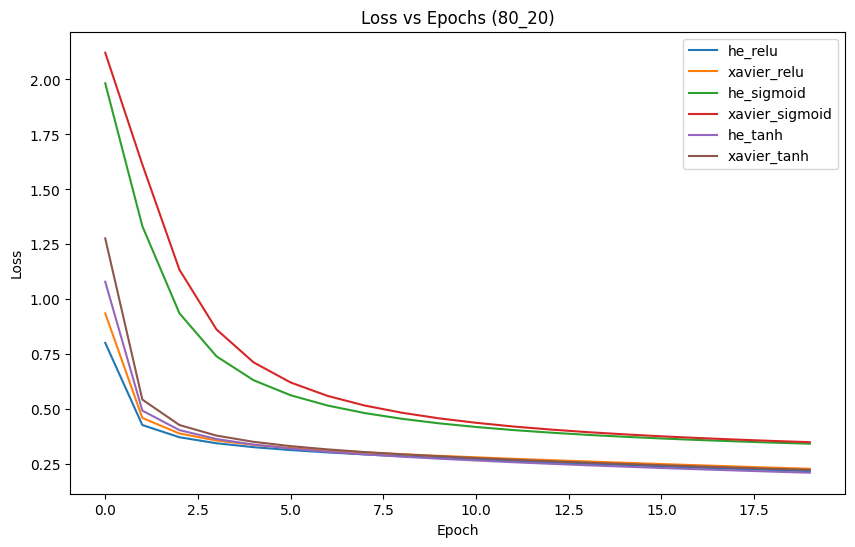

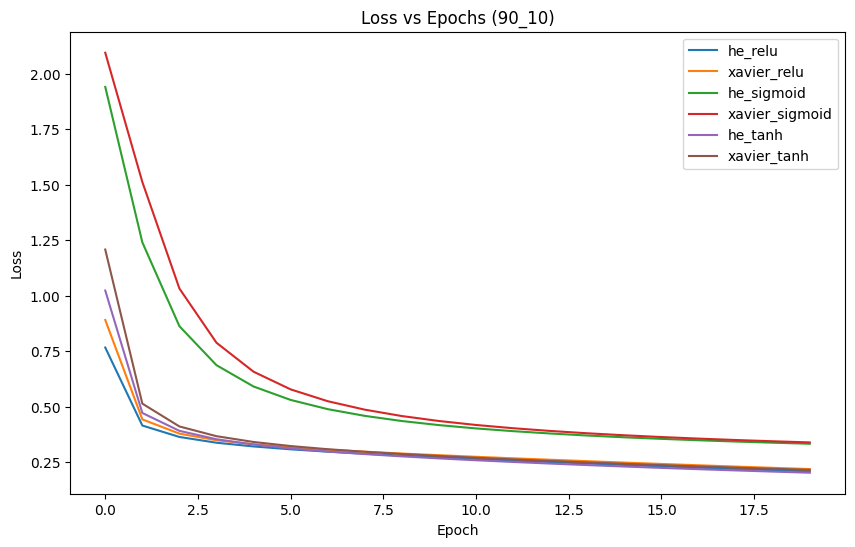

In [ ]:
for split_name, split_data in all_results.items():

    plt.figure(figsize=(10,6))

    for config_name, data in split_data.items():
        plt.plot(data["losses"], label=config_name)

    plt.title(f"Loss vs Epochs ({split_name})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [ ]:
for split_name, split_data in all_results.items():

    print(f"\n===== {split_name} RESULTS =====")

    for config_name, data in split_data.items():
        print(f"{config_name:20} | Acc: {data['test_acc']:.4f}")


===== 70_30 RESULTS =====
he_relu              | Acc: 0.9306
xavier_relu          | Acc: 0.9280
he_sigmoid           | Acc: 0.9014
xavier_sigmoid       | Acc: 0.8996
he_tanh              | Acc: 0.9347
xavier_tanh          | Acc: 0.9316

===== 80_20 RESULTS =====
he_relu              | Acc: 0.9364
xavier_relu          | Acc: 0.9326
he_sigmoid           | Acc: 0.9033
xavier_sigmoid       | Acc: 0.9028
he_tanh              | Acc: 0.9377
xavier_tanh          | Acc: 0.9346

===== 90_10 RESULTS =====
he_relu              | Acc: 0.9398
xavier_relu          | Acc: 0.9368
he_sigmoid           | Acc: 0.9077
xavier_sigmoid       | Acc: 0.9053
he_tanh              | Acc: 0.9420
xavier_tanh          | Acc: 0.9387


In [ ]:
for split_name, split_data in all_results.items():

    for config_name, data in split_data.items():
        print(f"\n{split_name} - {config_name}")
        print(data["conf_matrix"])


70_30 - he_relu
[[1722    1    8    3    6   26   19    4   16    0]
 [   0 1947   11    6    3    7    2    3   11    4]
 [   5   19 1603   15   20   12   26   26   25    8]
 [   6   11   36 1605    1   89    7   24   42   25]
 [   1    4    9    1 1642    0   18    4    4   43]
 [  16    7    7   22   11 1540   15    5   19   11]
 [   6    5   11    0   14   25 1714    1   10    1]
 [   5   17   34    2   20    4    0 1813    5   37]
 [   6   31   15   25   12   44   23    3 1554   17]
 [  12    7    6   13   49   14    0   43    8 1611]]

70_30 - xavier_relu
[[1722    1    6    3    6   28   16    6   17    0]
 [   0 1942   11    6    3    9    2    2   15    4]
 [   5   19 1600   14   20   14   27   26   26    8]
 [   6   10   38 1597    1   94    8   23   43   26]
 [   1    5   11    2 1636    0   18    3    3   47]
 [  16    9    9   23   10 1533   17    6   20   10]
 [   5    5   11    0   13   26 1715    2   10    0]
 [   5   18   34    1   21    3    0 1813    4   38]
 [   7 